# TF-IDF + Logistic Regression

This notebook implements Experiment 1 from the project proposal: TF-IDF text representation with a Logistic Regression classifier on the Truth Seeker dataset.

## Notes

- Input text comes from the `tweet` column after lowercasing, punctuation removal, and tokenization-style whitespace cleanup.
- Labels come from `BinaryNumTarget` where `1 = True` and `0 = False`.
- This notebook matches Experiment 1 in the proposal: `TF-IDF + Logistic Regression`.
- The notebook reports the proposal metrics: accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC.
- Binary precision, recall, F1, and ROC-AUC are computed using the `True (1)` class as the positive class.
- A 5-fold stratified cross-validation step is included before the final held-out test evaluation.

## 1. Import Libraries

In [7]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

## 2. Load and Clean the Dataset

In [ ]:
data_path = 'dataset/Truth_Seeker_Model_Dataset.csv'
df = pd.read_csv(data_path)

df = df[['tweet', 'BinaryNumTarget']].dropna()
df['BinaryNumTarget'] = df['BinaryNumTarget'].astype(int)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\\s]', ' ', text)
    tokens = text.split()
    return ' '.join(tokens)

df['clean_tweet'] = df['tweet'].astype(str).apply(clean_text)

# Match the sampling setup used in the other experiments in this repository.
df = df.sample(n=10000, random_state=42)

print('Dataset shape:', df.shape)
print(df[['tweet', 'clean_tweet', 'BinaryNumTarget']].head())
print('Class distribution:')
print(df['BinaryNumTarget'].value_counts())

Dataset shape: (10000, 2)
                                                    tweet  BinaryNumTarget
122451  @fattycattie @robquinnpc @SammyTMcCarty @WCCO ...                0
14029   never forget, Matt Santos ran on Medicare for ...                1
51449   @BilldeBlasio You are mandating an experimenta...                0
17981   @SenSanders The working class is literally bei...                1
66284   @PeterTong9 @timand2037 @ClimateAudit But none...                1
Class distribution:
BinaryNumTarget
1    5181
0    4819
Name: count, dtype: int64


## 3. Train/Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_tweet'],
    df['BinaryNumTarget'],
    test_size=0.2,
    random_state=42,
    stratify=df['BinaryNumTarget']\
)

print('Train size:', len(X_train))
print('Test size:', len(X_test))

Train size: 8000
Test size: 2000


## 4. Build TF-IDF + Logistic Regression Pipeline

In [10]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=False,
        stop_words='english',
        max_features=10000,
        ngram_range=(1, 2)
    )),
    ('logreg', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_metrics = {
    'accuracy': [],
    'true_precision': [],
    'true_recall': [],
    'true_f1': [],
    'roc_auc_true_class': []
}

for train_idx, val_idx in cv.split(df['clean_tweet'], df['BinaryNumTarget']):
    X_cv_train = df['clean_tweet'].iloc[train_idx]
    X_cv_val = df['clean_tweet'].iloc[val_idx]
    y_cv_train = df['BinaryNumTarget'].iloc[train_idx]
    y_cv_val = df['BinaryNumTarget'].iloc[val_idx]

    pipeline.fit(X_cv_train, y_cv_train)
    val_pred = pipeline.predict(X_cv_val)
    val_prob = pipeline.predict_proba(X_cv_val)
    true_val_prob = val_prob[:, 1]

    cv_metrics['accuracy'].append(accuracy_score(y_cv_val, val_pred))
    cv_metrics['true_precision'].append(precision_score(y_cv_val, val_pred, pos_label=1))
    cv_metrics['true_recall'].append(recall_score(y_cv_val, val_pred, pos_label=1))
    cv_metrics['true_f1'].append(f1_score(y_cv_val, val_pred, pos_label=1))
    cv_metrics['roc_auc_true_class'].append(roc_auc_score(y_cv_val, true_val_prob))

for metric, scores in cv_metrics.items():
    print(f'CV {metric}: {np.mean(scores):.4f} +/- {np.std(scores):.4f}')

pipeline.fit(X_train, y_train)
print('Training complete.')

Training complete.


## 5. Evaluate the Model

In [11]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)
true_prob = y_prob[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average='binary',
    pos_label=1
)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average='macro'
)
roc_auc = roc_auc_score(y_test, true_prob)
cm = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(f'True-class Precision: {precision:.4f}')
print(f'True-class Recall: {recall:.4f}')
print(f'True-class F1 Score: {f1:.4f}')
print(f'Macro Precision: {macro_precision:.4f}')
print(f'Macro Recall: {macro_recall:.4f}')
print(f'Macro F1 Score: {macro_f1:.4f}')
print(f'ROC-AUC (true class): {roc_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'True (1)'], digits=4))
print('Confusion Matrix:')
print(cm)

Accuracy: 0.9575
Precision: 0.9507
Recall: 0.9681
F1 Score: 0.9593
ROC-AUC: 0.9870

Classification Report:
              precision    recall  f1-score   support

           0     0.9651    0.9461    0.9555       964
           1     0.9507    0.9681    0.9593      1036

    accuracy                         0.9575      2000
   macro avg     0.9579    0.9571    0.9574      2000
weighted avg     0.9576    0.9575    0.9575      2000

Confusion Matrix:
[[ 912   52]
 [  33 1003]]


## 6. Visualize the Confusion Matrix

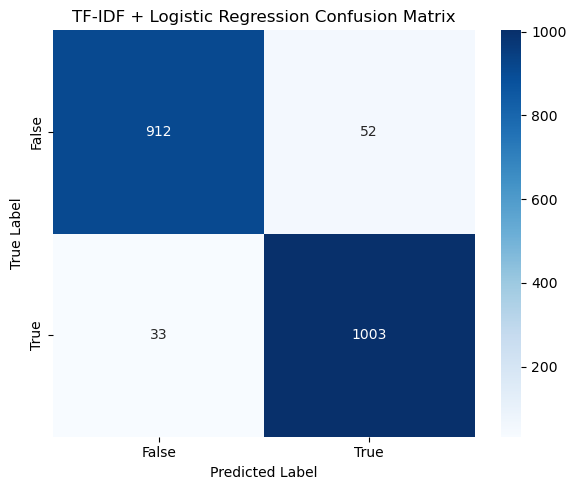

In [12]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Fake (0)', 'True (1)'], yticklabels=['Fake (0)', 'True (1)'])
plt.title('TF-IDF + Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## 7. Notes\n\n- Input text comes from the `tweet` column after lowercasing, punctuation removal, and tokenization-style whitespace cleanup.\n- Labels come from `BinaryNumTarget` where `1 = True` and `0 = False`.\n- This notebook matches Experiment 1 in the proposal: `TF-IDF + Logistic Regression`.\n- The notebook reports the proposal metrics: accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC.\n- Binary precision, recall, F1, and ROC-AUC are computed using the `True (1)` class as the positive class.\n- A 5-fold stratified cross-validation step is included before the final held-out test evaluation.